In [448]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [449]:
# read data into df
df = pd.read_csv(r"data/advertising.csv")
X = df.drop(columns=["Sales"]).values
y = df['Sales'].values

In [450]:
# apply StandartScaler

stscaler = StandardScaler()
stscaler.fit(X, y)
X = stscaler.transform(X)

converget at 522 step
coeffs =  [4.66255399 1.58126894 0.01071312]
intercept =  15.130048856000139


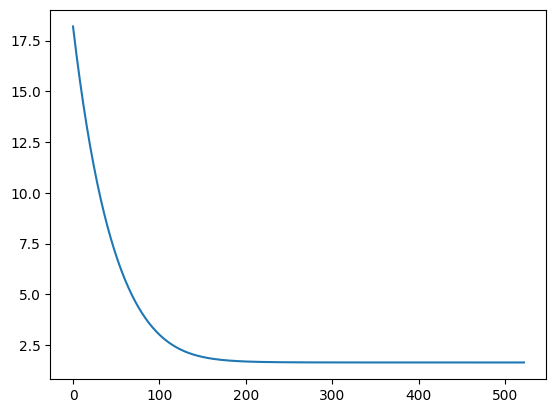

In [451]:
class BatchGradientDescent():
    def __init__(self, lr = 0.01, tol = 0.0001, max_iter = 1000):
        self.lr = lr
        self.tol = tol
        self.max_iter = max_iter
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]

        # define random coeff
        coeff = np.random.randn(n_features+1)

        self.rmses = []
        for step in range(self.max_iter):
            y_pred = X_bias @ coeff
            error = y - y_pred

            self.rmses.append(root_mean_squared_error(y, y_pred))

            gradd = (-2 / n_samples) * (X_bias.T @ error)

            if np.linalg.norm(gradd*self.lr, ord=1) < self.tol:
                print(f'converget at {step} step')
                self.converged = True
                break
            
            coeff = coeff - self.lr * gradd

        if not self.converged:
            print(f'Not converget at {self.max_iter} step')

        self.coeff_ = coeff[1:]
        self.intercept_ = coeff[0]
        return self
    
    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_
        
    
bgd = BatchGradientDescent()
bgd.fit(X, y)
print("coeffs = ", bgd.coeff_)
print("intercept = ", bgd.intercept_)

import matplotlib.pyplot as plt
plt.plot(bgd.rmses)
plt.show()




In [452]:
from sklearn.linear_model import SGDRegressor

sgdr = SGDRegressor()
sgdr.fit(X, y)
sgdr.predict(X)

print("coeffs = ", sgdr.coef_)
print("intercept = ", sgdr.intercept_)

coeffs =  [4.65459568 1.57246478 0.01317936]
intercept =  [15.12196219]


Not converged after 1000 epochs
coeffs =  [4.78367389 1.51953766 0.09688157]
intercept =  15.122228963981495


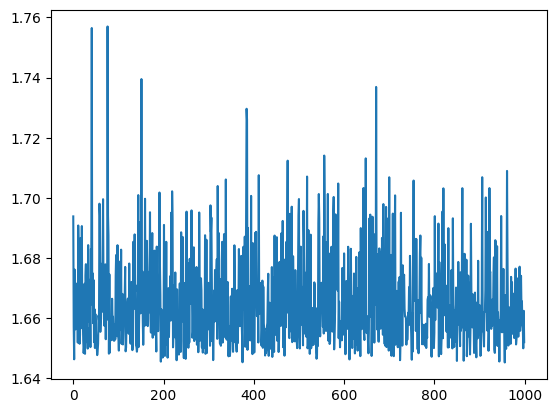

In [453]:
# rmses in epoch

import numpy as np

class StochasticGradientDescent2:
    def __init__(self, lr=0.1, tol=0.001, epoch=1000):
        self.lr = lr
        self.tol = tol
        self.epoch = epoch
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
        self.rmses = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        coeff = np.random.randn(n_features + 1)

        for step in range(self.epoch):
            indices = np.random.permutation(n_samples)
            X_bias_shuffled = X_bias[indices]
            y_shuffled = y[indices]

            coeff_old = coeff.copy()

            for i in range(n_samples):
                xi = X_bias_shuffled[i]
                yi = y_shuffled[i]
                y_pred = xi @ coeff
                error = yi - y_pred
                gradient = -2 * xi * error
                coeff -= self.lr * gradient

            delta = np.linalg.norm(coeff_old-coeff, ord=2)
            rmse = np.sqrt(np.mean((y_shuffled - X_bias_shuffled @ coeff)**2))
            self.rmses.append(rmse)

            if delta < self.tol:
                print(f"Converged at epoch {step}")
                self.converged = True
                break

        if not self.converged:
            print(f"Not converged after {self.epoch} epochs")

        self.intercept_ = coeff[0]
        self.coeff_ = coeff[1:]
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_
    

sgd = StochasticGradientDescent2(lr=0.01, tol=1e-3, epoch=1000)
sgd.fit(X, y)

print("coeffs = ", sgd.coeff_)
print("intercept = ", sgd.intercept_)

import matplotlib.pyplot as plt

plt.plot(sgd.rmses)
plt.show()


Converged at epoch 0
coeffs =  [4.83461411 1.30667524 0.01720389]
intercept =  14.898801383859869


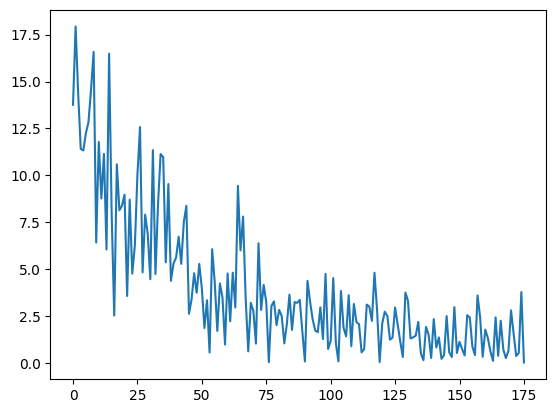

In [454]:
# rmses in inner loop

import numpy as np

class StochasticGradientDescent:
    def __init__(self, lr=0.1, tol=0.001, epoch=1000):
        self.lr = lr
        self.tol = tol
        self.epoch = epoch
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
        self.rmses = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        coeff = np.random.randn(n_features + 1)

        for step in range(self.epoch):
            indices = np.random.permutation(n_samples)
            X_bias_shuffled = X_bias[indices]
            y_shuffled = y[indices]

            for i in range(n_samples):
                xi = X_bias_shuffled[i]
                yi = y_shuffled[i]
                y_pred = xi @ coeff
                error = yi - y_pred
                gradient = -2 * xi * error
                coeff -= self.lr * gradient

                delta = np.linalg.norm(self.lr * gradient, ord=2)
                rmse = np.abs(yi - y_pred)
                self.rmses.append(rmse)

                if delta < self.tol:
                    print(f"Converged at epoch {step}")
                    self.converged = True
                    break
            if self.converged:
                break

        if not self.converged:
            print(f"Not converged after {self.epoch} epochs")

        self.intercept_ = coeff[0]
        self.coeff_ = coeff[1:]
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_
    

sgd = StochasticGradientDescent(lr=0.01, tol=0.001, epoch=1000)
sgd.fit(X, y)

print("coeffs = ", sgd.coeff_)
print("intercept = ", sgd.intercept_)

import matplotlib.pyplot as plt

plt.plot(sgd.rmses)
plt.show()


Converged at epoch 77
coeffs =  [4.66187499 1.58838103 0.00491608]
intercept =  15.12547192124546


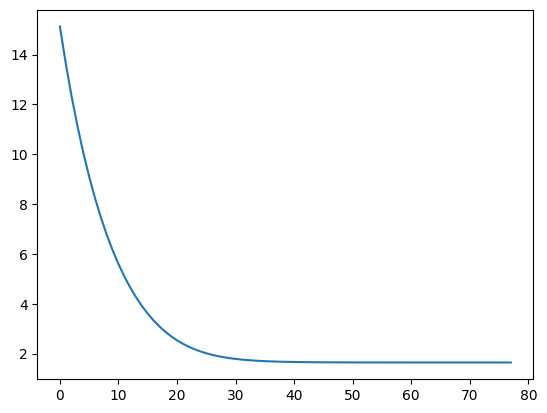

In [455]:
# rmses in epoch

import numpy as np

class BatchStochasticGradientDescent:
    def __init__(self, lr=0.01, tol=1e-4, epoch=1000, batch_size = 1):
        self.lr = lr
        self.tol = tol
        self.epoch = epoch
        self.batch_size = batch_size
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
        self.rmses = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        coeff = np.random.randn(n_features + 1)

        for step in range(self.epoch):
            indices = np.random.permutation(n_samples)
            X_bias_shuffled = X_bias[indices]
            y_shuffled = y[indices]

            coeff_old = coeff.copy()

            for i in range(0, n_samples, self.batch_size):
                xi = X_bias_shuffled[i:i+self.batch_size]
                yi = y_shuffled[i:i+self.batch_size]
                y_pred = xi @ coeff
                error = yi - y_pred
                gradient = -2 * xi.T @ error / len(xi)
                coeff -= self.lr * gradient

            delta = np.linalg.norm(coeff_old - coeff, ord=2)
            rmse = np.sqrt(np.mean((y_shuffled - X_bias_shuffled @ coeff)**2))
            self.rmses.append(rmse)

            if delta < self.tol:
                print(f"Converged at epoch {step}")
                self.converged = True
                break

        if not self.converged:
            print(f"Not converged after {self.epoch} epochs")

        self.intercept_ = coeff[0]
        self.coeff_ = coeff[1:]
        return self


    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_
    

bsgd = BatchStochasticGradientDescent(lr=0.01, tol=1e-3, epoch=1000, batch_size = 40)
bsgd.fit(X, y)

print("coeffs = ", bsgd.coeff_)
print("intercept = ", bsgd.intercept_)

import matplotlib.pyplot as plt

plt.plot(bsgd.rmses)
plt.show()


Converged at epoch 529
coeffs =  [4.67127692 1.58031948 0.00975382]
intercept =  15.129332677601335


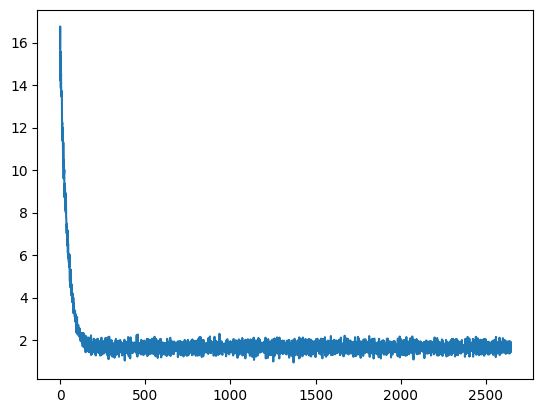

In [456]:
# rmses in inner loop

import numpy as np

class BatchStochasticGradientDescent:
    def __init__(self, lr=0.01, tol=1e-4, epoch=1000, batch_size = 1):
        self.lr = lr
        self.tol = tol
        self.epoch = epoch
        self.batch_size = batch_size
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
        self.rmses = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        coeff = np.random.randn(n_features + 1)

        for step in range(self.epoch):
            indices = np.random.permutation(n_samples)
            X_bias_shuffled = X_bias[indices]
            y_shuffled = y[indices]



            for i in range(0, n_samples, self.batch_size):
                xi = X_bias_shuffled[i:i+self.batch_size]
                yi = y_shuffled[i:i+self.batch_size]
                y_pred = xi @ coeff
                error = yi - y_pred
                gradient = -2 * xi.T @ error / len(xi)
                coeff -= self.lr * gradient

                delta = np.linalg.norm(self.lr * gradient, ord=2)
                rmse = np.sqrt(np.mean((yi - xi @ coeff)**2))
                self.rmses.append(rmse)

                if delta < self.tol:
                    print(f"Converged at epoch {step}")
                    self.converged = True
                    break
            if self.converged:
                break

        if not self.converged:
            print(f"Not converged after {self.epoch} epochs")

        self.intercept_ = coeff[0]
        self.coeff_ = coeff[1:]
        return self


    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_
    

bsgd = BatchStochasticGradientDescent(lr=0.01, tol=1e-3, epoch=1000, batch_size = 40)
bsgd.fit(X, y)

print("coeffs = ", bsgd.coeff_)
print("intercept = ", bsgd.intercept_)

import matplotlib.pyplot as plt

plt.plot(bsgd.rmses)
plt.show()


Converged at epoch 802
Converged at epoch 1
converget at 499 step


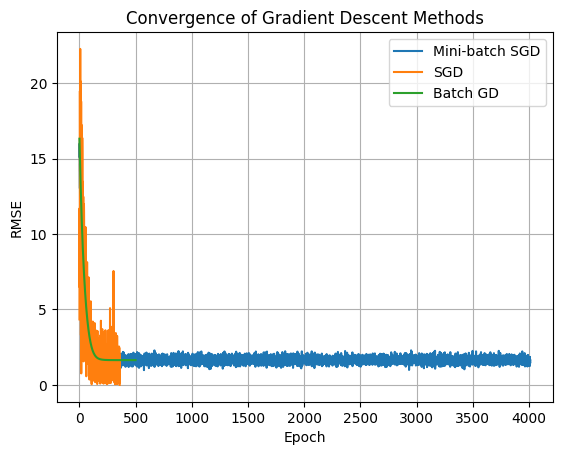

In [462]:
#barchasi bitta rasmda
import matplotlib.pyplot as plt




bsgd = BatchStochasticGradientDescent(lr=0.01, tol=1e-3, epoch=1000, batch_size=40)
bsgd.fit(X, y)
plt.plot(bsgd.rmses, label='Mini-batch SGD')

sgd = StochasticGradientDescent(lr=0.01, tol=0.001, epoch=1000)
sgd.fit(X, y)
plt.plot(sgd.rmses, label='SGD')

bgd = BatchGradientDescent()
bgd.fit(X, y)
plt.plot(bgd.rmses, label='Batch GD')

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Convergence of Gradient Descent Methods')
plt.legend()
plt.grid(True)

plt.show()
